In [1]:
import json
import math
import pickle
import re
import unicodedata
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

### Load Data

In [3]:
data_dir = Path('../../datasets/processed_data')
split_dir = Path('../../datasets/split_data')

# Processed BIO sequences
with open(data_dir / 'processed.pkl', 'rb') as f:
    processed = pickle.load(f)

# Vocabularies
with open(data_dir / 'vocabs.pkl', 'rb') as f:
    v = pickle.load(f)
    Entity_labels = v['Entity_labels']
    token2id = v['token2id']
    id2token = v['id2token']
    label2id = v['label2id']
    id2label = v['id2label']

# Train / val / test split indices (shared across all models)
with open(split_dir / 'split_indices.json') as f:
    split = json.load(f)
idx_train = split['idx_train']
idx_val = split['idx_val']
idx_test = split['idx_test']

print(f"Resumes loaded : {len(processed)}")
print(f"Entity labels  : {Entity_labels}")
print(f"Train / Val / Test : {len(idx_train)} / {len(idx_val)} / {len(idx_test)}")

Resumes loaded : 220
Entity labels  : ['Name', 'Designation', 'Companies worked at', 'Location', 'Email Address', 'College Name', 'Degree', 'Graduation Year', 'Skills', 'Years of Experience']
Train / Val / Test : 154 / 33 / 33


### BIO Sequence Extraction

In [6]:
def get_sequences(indices):
    """Return (token_sequences, tag_sequences) for the given resume indices."""
    tokens_list, tags_list = [], []
    for i in indices:
        bio = processed[i]['word_bio_norm']
        tokens_list.append([tok for tok, _ in bio])
        tags_list.append([tag for _, tag in bio])
    return tokens_list, tags_list

train_tokens, train_tags = get_sequences(idx_train)
val_tokens, val_tags = get_sequences(idx_val)
test_tokens, test_tags = get_sequences(idx_test)

all_train_tokens = train_tokens + val_tokens  # used for final model
all_train_tags = train_tags   + val_tags

print(f"Train seqs : {len(train_tokens)}")
print(f"Val seqs   : {len(val_tokens)}")
print(f"Test seqs  : {len(test_tokens)}")

Train seqs : 154
Val seqs   : 33
Test seqs  : 33


### Word Similarity Feature

In [7]:
def char_trigrams(word: str) -> set:
    """Return the set of character trigrams for a word."""
    w = f"  {word}  "   # boundary padding
    return {w[i:i+3] for i in range(len(w) - 2)}


def trigram_similarity(w1: str, w2: str) -> float:
    """Jaccard similarity between the trigram sets of two words."""
    t1, t2 = char_trigrams(w1), char_trigrams(w2)
    inter = len(t1 & t2)
    union = len(t1 | t2)
    return inter / union if union else 0.0


def build_similarity_index(
    vocab: list[str],
    top_k: int = 10,
    min_sim: float = 0.2
) -> dict[str, list[tuple[str, float]]]:
    """
    For every word in vocab, precompute the top-k most similar words
    (by trigram Jaccard) with similarity >= min_sim.

    Returns
    -------
    sim_index : dict  word -> [(similar_word, similarity), ...]
    """
    sim_index = {}
    vocab_list = list(vocab)
    n = len(vocab_list)
    for i, w1 in enumerate(vocab_list):
        sims = []
        for j, w2 in enumerate(vocab_list):
            if i == j:
                continue
            s = trigram_similarity(w1, w2)
            if s >= min_sim:
                sims.append((w2, s))
        sims.sort(key=lambda x: -x[1])
        sim_index[w1] = sims[:top_k]
    return sim_index


# Build vocabulary from training tokens
train_vocab = sorted({tok for seq in all_train_tokens for tok in seq})
print(f"Training vocabulary size: {len(train_vocab):,}")
print("Building similarity index (may take ~30 s for large vocab) ...")

sim_index = build_similarity_index(train_vocab, top_k=10, min_sim=0.2)
print("Done.")

# Quick demo
demo_word = "engineer"
print(f"\nTop similar words to '{demo_word}':")
for w, s in sim_index.get(demo_word, [])[:5]:
    print(f"  {w:<25}  sim={s:.3f}")

Training vocabulary size: 7,815
Building similarity index (may take ~30 s for large vocab) ...
Done.

Top similar words to 'engineer':
  enginner                   sim=0.538
  engineering                sim=0.533
  engine                     sim=0.500
  enginerre                  sim=0.400
  reengineere                sim=0.353


### Parameter Estimation

In [ ]:
class HiddenMarkovModel:
    """
    First-order HMM for BIO-tag sequence labelling.

    Parameters
    ----------
    alpha : float
        Laplace smoothing for transition & emission counts.
    lam : float
        Similarity-smoothing mixture weight (0 = no smoothing, 1 = full).
    sim_index : dict
        Precomputed word-similarity index  word -> [(sim_word, score), ...].
    """

    # Special BIO boundary tag
    START = '<START>'
    END = '<END>'

    def __init__(
        self,
        alpha: float = 1.0,
        lam:   float = 0.1,
        sim_index: dict | None = None,
    ):
        self.alpha = alpha
        self.lam = lam
        self.sim_index = sim_index or {}

        # Will be filled during fit()
        self.tags_: list[str] = []
        self.vocab_: set[str] = set()
        self.tag2id_: dict[str, int] = {}
        self.id2tag_: dict[int, str] = {}

        # Raw count tables
        self._trans_counts: dict = defaultdict(lambda: defaultdict(int))
        self._emit_counts: dict = defaultdict(lambda: defaultdict(int))
        self._tag_counts: dict = defaultdict(int)
        self._init_counts: dict = defaultdict(int)

        # Log-probability tables (filled by _finalize)
        self.log_trans_: np.ndarray | None = None   # (n_tags, n_tags)
        self.log_init_: np.ndarray | None = None   # (n_tags,)

    # Fitting

    def fit(self, token_seqs: list[list[str]], tag_seqs: list[list[str]]):
        """Estimate HMM parameters from labelled token/tag sequences."""
        assert len(token_seqs) == len(tag_seqs)

        # Collect tag / vocab universe
        for tags in tag_seqs:
            for t in tags:
                self._tag_counts[t] += 0   # just register
        self.tags_ = sorted(self._tag_counts.keys())
        self.tag2id_ = {t: i for i, t in enumerate(self.tags_)}
        self.id2tag_ = {i: t for t, i in self.tag2id_.items()}

        # Count transitions, emissions, initial tags
        for tokens, tags in zip(token_seqs, tag_seqs):
            self._init_counts[tags[0]] += 1
            for i, (tok, tag) in enumerate(zip(tokens, tags)):
                self._tag_counts[tag] += 1
                self._emit_counts[tag][tok] += 1
                self.vocab_.add(tok)
                if i > 0:
                    self._trans_counts[tags[i - 1]][tag] += 1

        self._finalize()
        return self

    def _finalize(self):
        """Convert counts to smoothed log-probability matrices."""
        n = len(self.tags_)
        a = self.alpha

        # Initial log-probs
        total_init = sum(self._init_counts.values())
        log_init = np.array([
            math.log((self._init_counts[t] + a) / (total_init + a * n))
            for t in self.tags_
        ])
        self.log_init_ = log_init

        # Transition log-probs (n x n matrix)
        log_trans = np.full((n, n), -np.inf)
        for i, t_from in enumerate(self.tags_):
            cnt_from = self._tag_counts[t_from]
            for j, t_to in enumerate(self.tags_):
                cnt = self._trans_counts[t_from][t_to]
                log_trans[i, j] = math.log((cnt + a) / (cnt_from + a * n))
        self.log_trans_ = log_trans

    # Emission (with similarity smoothing, computed on-the-fly)
    def _log_emit(self, word: str, tag: str) -> float:
        """
        Smoothed log-emission probability for (word, tag).

        For in-vocabulary words:
            P_smooth = (1-lam)*P_ML + lam * similarity-weighted mixture

        For OOV words:
            P_smooth = lam * similarity-weighted mixture  (no ML term)
            Falls back to uniform if no similar in-vocab words found.
        """
        a = self.alpha
        tag_cnt = self._tag_counts[tag]
        vocab_sz = len(self.vocab_)

        # Maximum-likelihood emission (Laplace smoothed)
        emit_cnt = self._emit_counts[tag][word]
        p_ml = (emit_cnt + a) / (tag_cnt + a * vocab_sz)

        # Similarity-smoothed component
        sim_neighbours = self.sim_index.get(word, [])
        if sim_neighbours and self.lam > 0:
            sim_sum = sum(s for _, s in sim_neighbours)
            p_sim = 0.0
            for nb_word, sim_score in sim_neighbours:
                nb_cnt = self._emit_counts[tag][nb_word]
                p_nb = (nb_cnt + a) / (tag_cnt + a * vocab_sz)
                p_sim += (sim_score / sim_sum) * p_nb
            p_smooth = (1.0 - self.lam) * p_ml + self.lam * p_sim
        else:
            p_smooth = p_ml

        # Guard against zero / negative
        if p_smooth <= 0:
            p_smooth = 1e-300
        return math.log(p_smooth)

    # Viterbi Decoding

    def predict_single(self, tokens: list[str]) -> list[str]:
        """
        Viterbi decoding for one token sequence.

        Returns the most-likely BIO tag sequence.
        """
        n_tags = len(self.tags_)
        T = len(tokens)
        if T == 0:
            return []
        # viterbi[t][j] = max log-prob of any path ending in tag j at position t
        # backptr[t][j] = argmax tag at position t-1
        viterbi = np.full((T, n_tags), -np.inf)
        backptr = np.zeros((T, n_tags), dtype=int)

        # --- Initialisation (t=0) ---
        for j, tag in enumerate(self.tags_):
            viterbi[0, j] = self.log_init_[j] + self._log_emit(tokens[0], tag)

        # --- Recursion ---
        for t in range(1, T):
            for j, tag_j in enumerate(self.tags_):
                log_e = self._log_emit(tokens[t], tag_j)
                scores = viterbi[t - 1, :] + self.log_trans_[:, j] + log_e
                best_i = int(np.argmax(scores))
                viterbi[t, j] = scores[best_i]
                backptr[t, j] = best_i

        # --- Backtrack ---
        tags_out = [int(np.argmax(viterbi[T - 1, :]))]
        for t in range(T - 1, 0, -1):
            tags_out.append(backptr[t, tags_out[-1]])
        tags_out.reverse()

        return [self.id2tag_[idx] for idx in tags_out]

    def predict(self, token_seqs: list[list[str]]) -> list[list[str]]:
        """Batch Viterbi decoding."""
        return [self.predict_single(seq) for seq in token_seqs]


print("HiddenMarkovModel class defined.")

HiddenMarkovModel class defined.


### Hyperparameter Tuning

In [11]:
alpha_values = [0.001, 0.01, 0.1, 1.0]
lam_values = [0.0, 0.05, 0.1, 0.2]

grid_results = []

print(f"Grid search: {len(alpha_values)}x{len(lam_values)} = "f"{len(alpha_values)*len(lam_values)} combos")
print(f"{'alpha':<10} {'lam':<8} {'Val F1':>10}")
print("=" * 32)

for alpha in alpha_values:
    for lam in lam_values:
        hmm = HiddenMarkovModel(alpha=alpha, lam=lam, sim_index=sim_index)
        hmm.fit(train_tokens, train_tags)
        y_pred_val = hmm.predict(val_tokens)
        f1 = f1_score(val_tags, y_pred_val)
        grid_results.append({'alpha': alpha, 'lam': lam, 'val_f1': f1})
        print(f"{alpha:<10} {lam:<8} {f1:>10.4f}")

best = max(grid_results, key=lambda x: x['val_f1'])
print(f"\nBest -> alpha={best['alpha']}, lam={best['lam']}, " f"val_f1={best['val_f1']:.4f}")

Grid search: 4x4 = 16 combos
alpha      lam          Val F1
0.001      0.0          0.2599
0.001      0.05         0.4378
0.001      0.1          0.4399
0.001      0.2          0.4390
0.01       0.0          0.2772
0.01       0.05         0.3834
0.01       0.1          0.3962
0.01       0.2          0.4418
0.1        0.0          0.2799
0.1        0.05         0.3315
0.1        0.1          0.3516
0.1        0.2          0.3674
1.0        0.0          0.2376
1.0        0.05         0.2349
1.0        0.1          0.2373
1.0        0.2          0.2181

Best -> alpha=0.01, lam=0.2, val_f1=0.4418


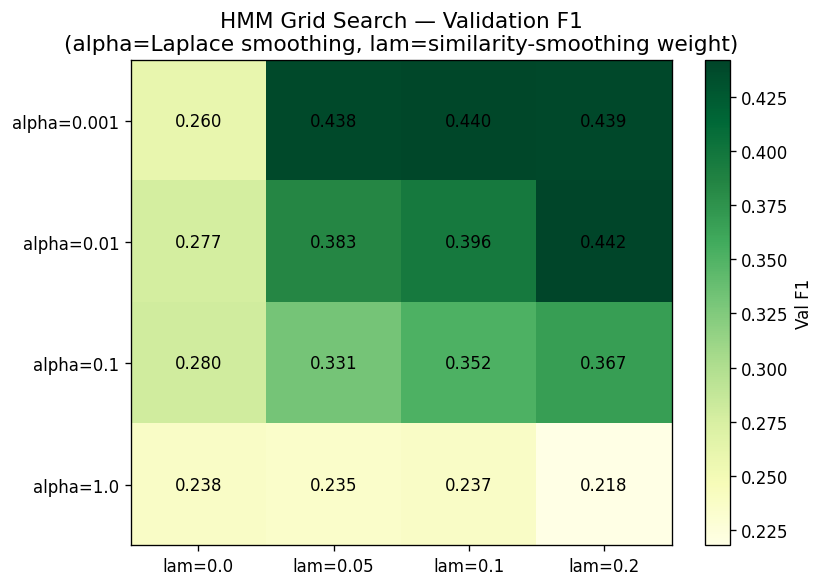

In [12]:
# Visualise grid-search heatmap
grid_df = pd.DataFrame(grid_results)
pivot = grid_df.pivot(index='alpha', columns='lam', values='val_f1')

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto')
ax.set_xticks(range(len(lam_values)))
ax.set_yticks(range(len(alpha_values)))
ax.set_xticklabels([f'lam={v}' for v in lam_values])
ax.set_yticklabels([f'alpha={v}' for v in alpha_values])
for i in range(len(alpha_values)):
    for j in range(len(lam_values)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, label="Val F1")
ax.set_title("HMM Grid Search — Validation F1\n(alpha=Laplace smoothing, lam=similarity-smoothing weight)")
plt.tight_layout()
plt.show()

### Final Model Training

In [14]:
hmm_final = HiddenMarkovModel(
    alpha = best['alpha'],
    lam = best['lam'],
    sim_index = sim_index,
)
hmm_final.fit(all_train_tokens, all_train_tags)

print(f"Final HMM trained on {len(all_train_tokens)} resumes")
print(f"alpha={best['alpha']}, lam={best['lam']}")
print(f"Tags   : {len(hmm_final.tags_)}")
print(f"Vocab  : {len(hmm_final.vocab_):,} tokens")

Final HMM trained on 187 resumes
alpha=0.01, lam=0.2
Tags   : 20
Vocab  : 7,815 tokens


### Probability Distribution Inspection

Trasition Matrix

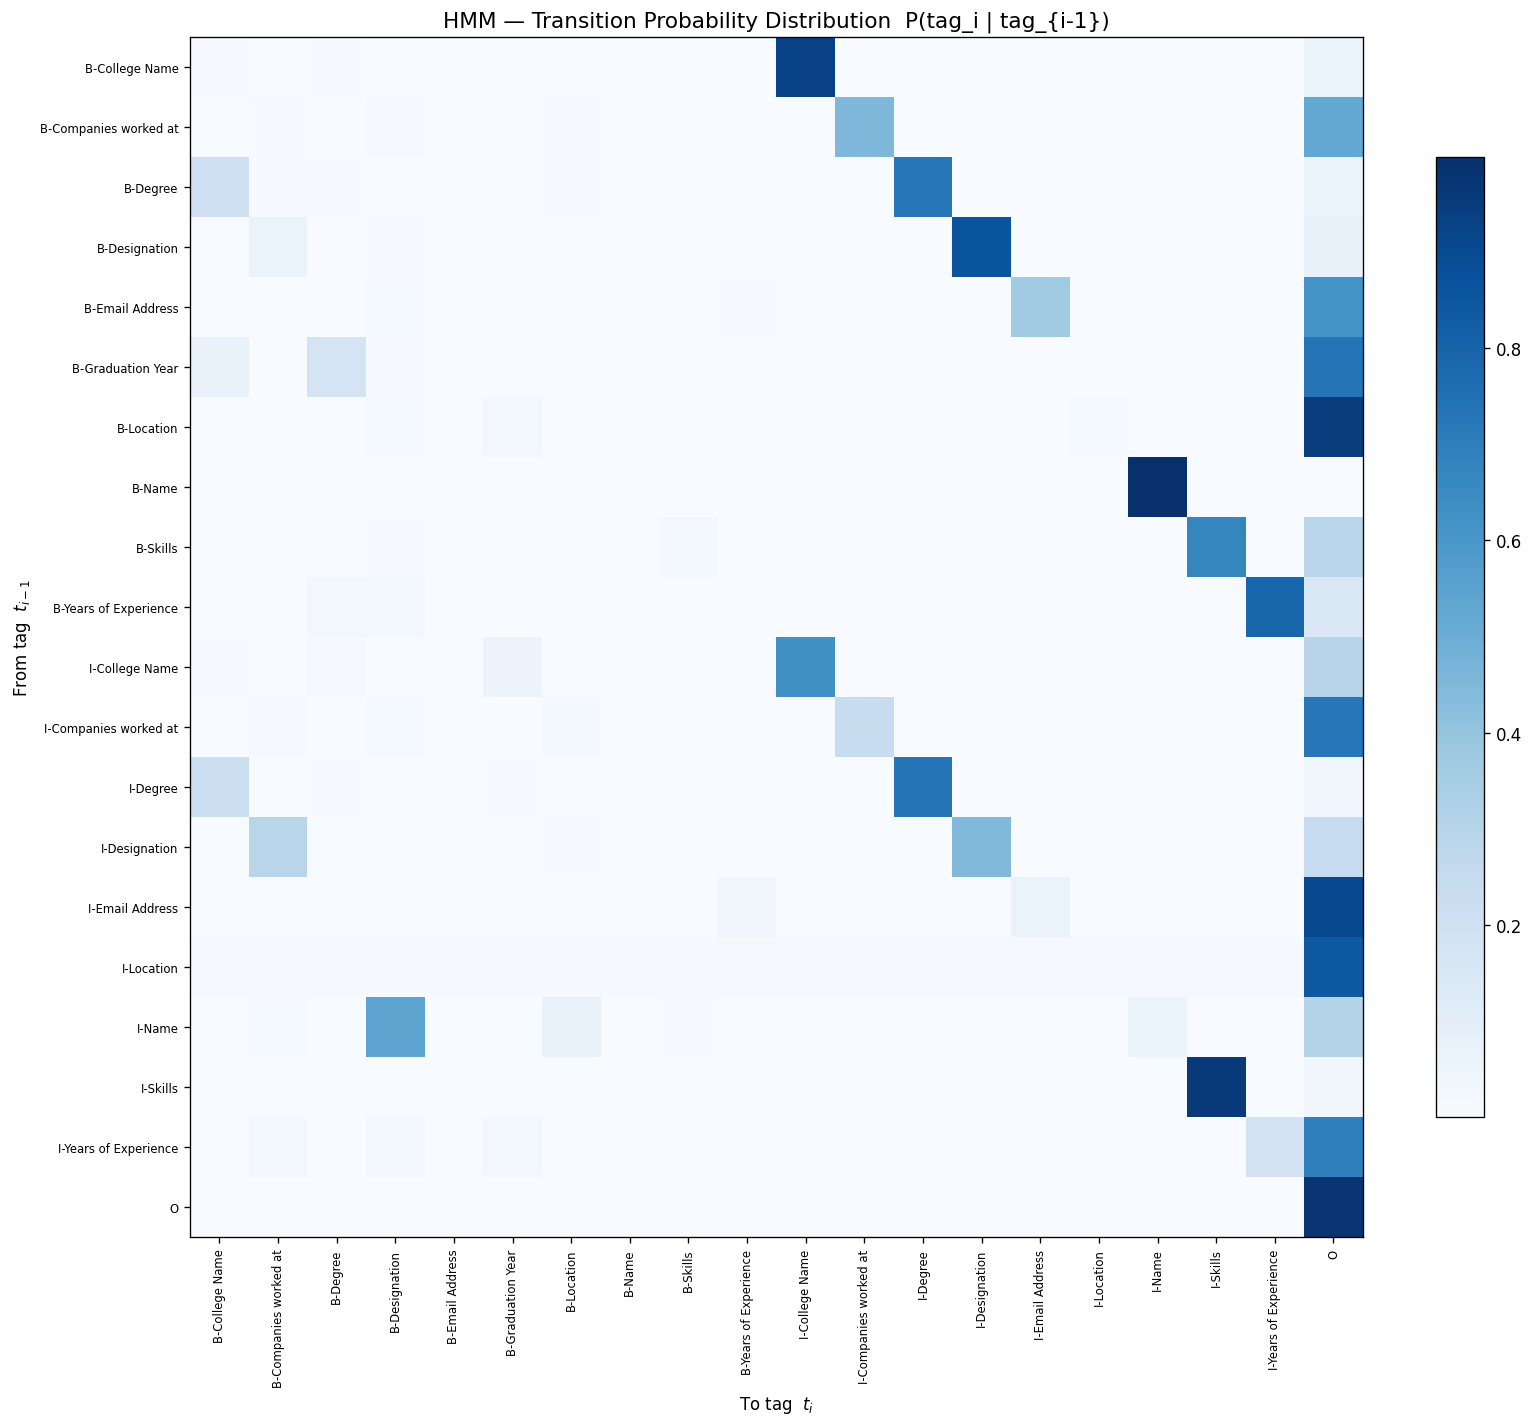

In [15]:
# Convert log-probs back to probabilities for display
trans_probs = np.exp(hmm_final.log_trans_)
tag_labels = hmm_final.tags_

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(trans_probs, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(tag_labels)))
ax.set_yticks(range(len(tag_labels)))
ax.set_xticklabels(tag_labels, rotation=90, fontsize=7)
ax.set_yticklabels(tag_labels, fontsize=7)
ax.set_xlabel("To tag  $t_i$")
ax.set_ylabel("From tag  $t_{i-1}$")
ax.set_title("HMM — Transition Probability Distribution  P(tag_i | tag_{i-1})")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()